In [1]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv('train_aWnotuB.csv')
# In Parsons projects, time is everything. Let's convert DateTime from object to real-time format.
df['DateTime'] = pd.to_datetime(df['DateTime'])
# Feature Engineering
# As a Data Engineer, let's extract new meaning from raw data
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()

# Show your diligence as an intern
df.drop_duplicates(inplace=True)
df = df.dropna()

# Junction-Based Grouping
# Which junction has the most traffic?
junction_summary = df.groupby('Junction')['Vehicles'].sum().reset_index()

print("Cleaning and Feature Extraction Complete!")
print(df.head())

Cleaning and Feature Extraction Complete!
             DateTime  Junction  Vehicles           ID  Year  Month  Day  \
0 2015-11-01 00:00:00         1        15  20151101001  2015     11    1   
1 2015-11-01 01:00:00         1        13  20151101011  2015     11    1   
2 2015-11-01 02:00:00         1        10  20151101021  2015     11    1   
3 2015-11-01 03:00:00         1         7  20151101031  2015     11    1   
4 2015-11-01 04:00:00         1         9  20151101041  2015     11    1   

   Hour DayOfWeek  
0     0    Sunday  
1     1    Sunday  
2     2    Sunday  
3     3    Sunday  
4     4    Sunday  


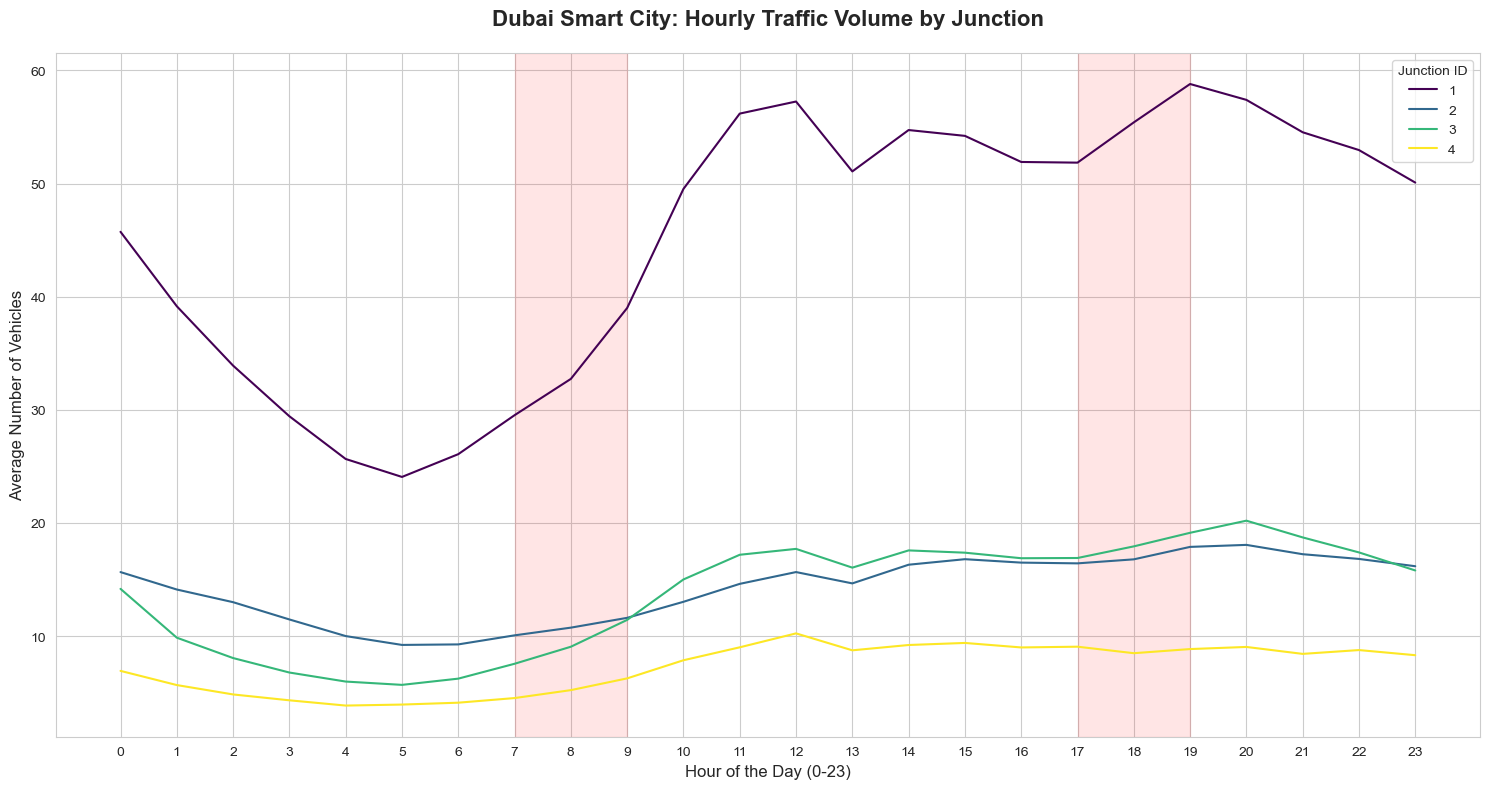

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

sns.lineplot(data=df, x='Hour', y='Vehicles', hue='Junction', palette='viridis', errorbar=None)
#Customize the chart for Parsons Presentation
plt.title('Dubai Smart City: Hourly Traffic Volume by Junction', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Number of Vehicles', fontsize=12)
plt.xticks(range(0, 24)) 


plt.legend(title='Junction ID', loc='upper right', frameon=True)

plt.axvspan(7, 9, color='red', alpha=0.1, label='Morning Peak')
plt.axvspan(17, 19, color='red', alpha=0.1, label='Evening Peak')

plt.tight_layout()
plt.show()